
Epoch 0
Loss: 0.700309
fc1.weight | mean: -0.028378114104270935 std: 0.41198956966400146
fc1.bias   | mean: -0.028566494584083557
fc2.weight | mean: -0.0010729223722591996 std: 0.0717083215713501
fc2.bias   | mean: 0.004468400962650776
fc3.weight | mean: -0.014117235317826271 std: 0.07331772148609161
fc3.bias   | mean: 0.09402468800544739
------------------------------------------------------------

Epoch 20
Loss: 0.636754
fc1.weight | mean: -0.02841196209192276 std: 0.4121973216533661
fc1.bias   | mean: -0.02792779915034771
fc2.weight | mean: -0.0005904223071411252 std: 0.07181759923696518
fc2.bias   | mean: 0.007072414271533489
fc3.weight | mean: -0.02845020964741707 std: 0.07645518332719803
fc3.bias   | mean: -0.08205362409353256
------------------------------------------------------------

Epoch 40
Loss: 0.632346
fc1.weight | mean: -0.028540920466184616 std: 0.4123724699020386
fc1.bias   | mean: -0.02736707590520382
fc2.weight | mean: -0.0003164058143738657 std: 0.0719141289591789

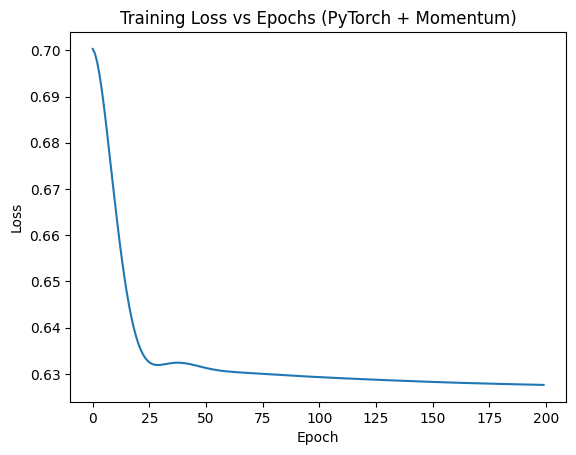

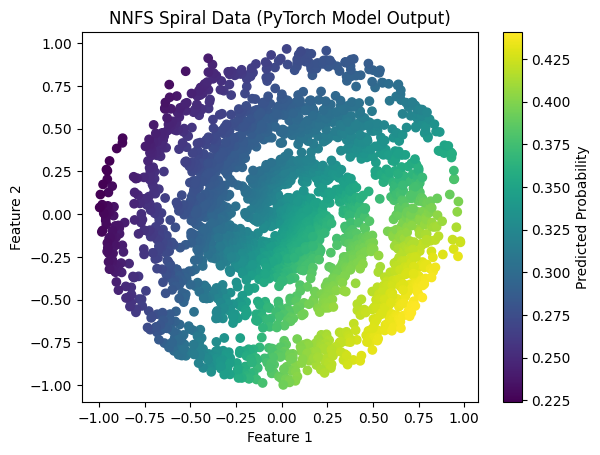

In [7]:
# =========================================================
# PyTorch: NNFS Spiral Dataset + Momentum Optimizer
# WITH WEIGHT & BIAS PRINTING
# =========================================================

import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from nnfs.datasets import spiral_data
import nnfs

# -----------------------------
# Init NNFS (reproducibility)
# -----------------------------
nnfs.init()
torch.manual_seed(0)

# -----------------------------
# Dataset (NNFS)
# -----------------------------
X, y = spiral_data(samples=1000, classes=3)

# Binary classification: class 0 vs rest
y = (y == 0).astype(int)

# Convert to PyTorch tensors
X = torch.tensor(X, dtype=torch.float32)
y = torch.tensor(y, dtype=torch.float32).unsqueeze(1)

# -----------------------------
# Model
# -----------------------------
class SpiralNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(2, 64)
        self.fc2 = nn.Linear(64, 64)
        self.fc3 = nn.Linear(64, 1)
        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.relu(self.fc1(x))
        x = self.relu(self.fc2(x))
        x = self.fc3(x)
        return x

model = SpiralNet()

# -----------------------------
# Loss + Optimizer (Momentum)
# -----------------------------
criterion = nn.BCEWithLogitsLoss()

optimizer = optim.SGD(
    model.parameters(),
    lr=0.01,
    momentum=0.9
)

# -----------------------------
# Training Loop
# -----------------------------
epochs = 200
loss_history = []

for epoch in range(epochs):

    optimizer.zero_grad()

    logits = model(X)
    loss = criterion(logits, y)

    loss.backward()
    optimizer.step()

    loss_history.append(loss.item())

    # -----------------------------
    # PRINT UPDATED WEIGHTS & BIASES
    # -----------------------------
    if epoch % 20 == 0:
        print(f"\nEpoch {epoch}")
        print(f"Loss: {loss.item():.6f}")

        print("fc1.weight | mean:", model.fc1.weight.mean().item(),
              "std:", model.fc1.weight.std().item())
        print("fc1.bias   | mean:", model.fc1.bias.mean().item())

        print("fc2.weight | mean:", model.fc2.weight.mean().item(),
              "std:", model.fc2.weight.std().item())
        print("fc2.bias   | mean:", model.fc2.bias.mean().item())

        print("fc3.weight | mean:", model.fc3.weight.mean().item(),
              "std:", model.fc3.weight.std().item())
        print("fc3.bias   | mean:", model.fc3.bias.mean().item())

        print("-" * 60)

# -----------------------------
# Visualization 1: Loss Curve
# -----------------------------
plt.figure()
plt.plot(loss_history)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss vs Epochs (PyTorch + Momentum)")
plt.show()

# -----------------------------
# Visualization 2: Spiral Data + Model Output
# -----------------------------
with torch.no_grad():
    outputs = torch.sigmoid(model(X))

plt.figure()
plt.scatter(X[:, 0], X[:, 1], c=outputs.squeeze(), cmap="viridis")
plt.colorbar(label="Predicted Probability")
plt.title("NNFS Spiral Data (PyTorch Model Output)")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()


Epoch 0
Loss: 0.693152
W1 shape: (2, 64)  | mean: -0.00058709877  | std: 0.010717006
b1 mean: -1.12802304e-07
W2 shape: (64, 64)  | mean: -3.938367e-05  | std: 0.00995929
b2 mean: -2.0363786e-06
W3 shape: (64, 1)  | mean: 0.00075651205  | std: 0.009556701
b3 mean: -0.0016667256
------------------------------------------------------------

Epoch 20
Loss: 0.666378
W1 shape: (2, 64)  | mean: -0.0005866324  | std: 0.010714953
b1 mean: -5.5999244e-06
W2 shape: (64, 64)  | mean: -3.918008e-05  | std: 0.009959222
b2 mean: 0.00016506993
W3 shape: (64, 1)  | mean: 0.0007256658  | std: 0.0095722005
b3 mean: -0.1988377
------------------------------------------------------------

Epoch 40
Loss: 0.646047
W1 shape: (2, 64)  | mean: -0.00058611814  | std: 0.010713576
b1 mean: -7.160655e-06
W2 shape: (64, 64)  | mean: -3.823867e-05  | std: 0.00995918
b2 mean: 0.0006473968
W3 shape: (64, 1)  | mean: 0.00063473184  | std: 0.009667202
b3 mean: -0.41256574
-----------------------------------------------

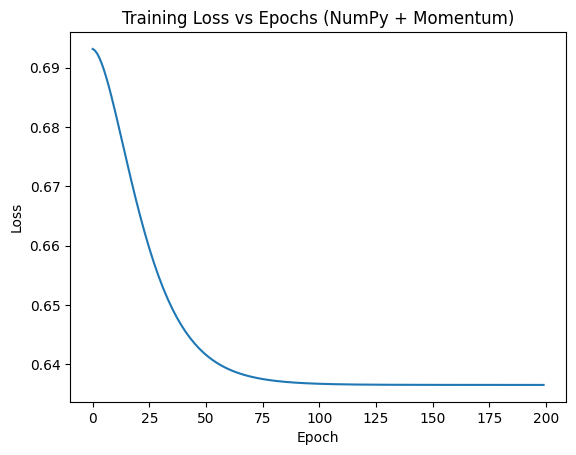

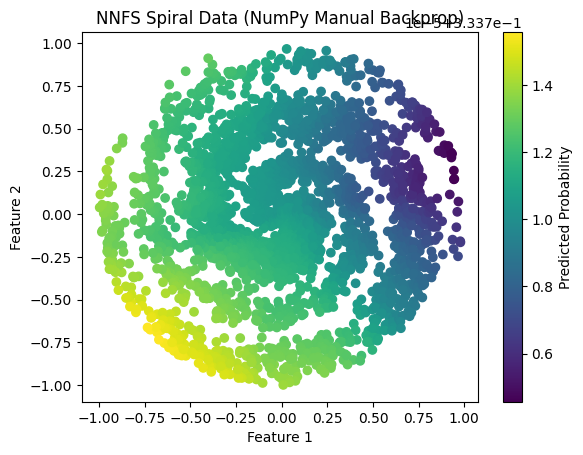

In [6]:
# =========================================================
# NumPy ONLY: NNFS Spiral Dataset
# Manual Backpropagation + Momentum Optimizer
# WITH WEIGHT & BIAS PRINTING
# =========================================================

import numpy as np
import matplotlib.pyplot as plt
from nnfs.datasets import spiral_data
import nnfs

nnfs.init()
np.random.seed(0)

# ---------------------------------------------------------
# Dataset (NNFS)
# ---------------------------------------------------------
X, y = spiral_data(samples=1000, classes=3)
y = (y == 0).astype(float).reshape(-1, 1)

N, D = X.shape

# ---------------------------------------------------------
# Model dimensions
# ---------------------------------------------------------
H1 = 64
H2 = 64
O = 1

# ---------------------------------------------------------
# Initialize weights & biases
# ---------------------------------------------------------
W1 = 0.01 * np.random.randn(D, H1)
b1 = np.zeros((1, H1))

W2 = 0.01 * np.random.randn(H1, H2)
b2 = np.zeros((1, H2))

W3 = 0.01 * np.random.randn(H2, O)
b3 = np.zeros((1, O))

# ---------------------------------------------------------
# Momentum velocities
# ---------------------------------------------------------
vW1 = np.zeros_like(W1)
vb1 = np.zeros_like(b1)

vW2 = np.zeros_like(W2)
vb2 = np.zeros_like(b2)

vW3 = np.zeros_like(W3)
vb3 = np.zeros_like(b3)

# ---------------------------------------------------------
# Hyperparameters
# ---------------------------------------------------------
lr = 0.01
momentum = 0.9
epochs = 200

# ---------------------------------------------------------
# Activation & Loss
# ---------------------------------------------------------
def relu(x):
    return np.maximum(0, x)

def relu_backward(dout, x):
    dx = dout.copy()
    dx[x <= 0] = 0
    return dx

def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def bce_loss(y_pred, y_true):
    eps = 1e-7
    y_pred = np.clip(y_pred, eps, 1 - eps)
    return -np.mean(
        y_true * np.log(y_pred) +
        (1 - y_true) * np.log(1 - y_pred)
    )

# ---------------------------------------------------------
# Training
# ---------------------------------------------------------
loss_history = []

for epoch in range(epochs):

    # ================= FORWARD =================
    z1 = X @ W1 + b1
    a1 = relu(z1)

    z2 = a1 @ W2 + b2
    a2 = relu(z2)

    z3 = a2 @ W3 + b3
    y_pred = sigmoid(z3)

    loss = bce_loss(y_pred, y)
    loss_history.append(loss)

    # ================= BACKWARD =================
    dL_dz3 = y_pred - y

    dW3 = a2.T @ dL_dz3 / N
    db3 = np.mean(dL_dz3, axis=0, keepdims=True)

    da2 = dL_dz3 @ W3.T
    dz2 = relu_backward(da2, z2)

    dW2 = a1.T @ dz2 / N
    db2 = np.mean(dz2, axis=0, keepdims=True)

    da1 = dz2 @ W2.T
    dz1 = relu_backward(da1, z1)

    dW1 = X.T @ dz1 / N
    db1 = np.mean(dz1, axis=0, keepdims=True)

    # ================= MOMENTUM UPDATE =================
    vW3 = momentum * vW3 + dW3
    vb3 = momentum * vb3 + db3
    W3 -= lr * vW3
    b3 -= lr * vb3

    vW2 = momentum * vW2 + dW2
    vb2 = momentum * vb2 + db2
    W2 -= lr * vW2
    b2 -= lr * vb2

    vW1 = momentum * vW1 + dW1
    vb1 = momentum * vb1 + db1
    W1 -= lr * vW1
    b1 -= lr * vb1

    # ================= PRINT UPDATED PARAMS =================
    if epoch % 20 == 0:
        print(f"\nEpoch {epoch}")
        print(f"Loss: {loss:.6f}")

        print("W1 shape:", W1.shape, " | mean:", W1.mean(), " | std:", W1.std())
        print("b1 mean:", b1.mean())

        print("W2 shape:", W2.shape, " | mean:", W2.mean(), " | std:", W2.std())
        print("b2 mean:", b2.mean())

        print("W3 shape:", W3.shape, " | mean:", W3.mean(), " | std:", W3.std())
        print("b3 mean:", b3.mean())

        print("-" * 60)

# ---------------------------------------------------------
# Visualization 1: Loss Curve
# ---------------------------------------------------------
plt.figure()
plt.plot(loss_history)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss vs Epochs (NumPy + Momentum)")
plt.show()

# ---------------------------------------------------------
# Visualization 2: Spiral Data + Predictions
# ---------------------------------------------------------
plt.figure()
plt.scatter(X[:, 0], X[:, 1], c=y_pred.squeeze(), cmap="viridis")
plt.colorbar(label="Predicted Probability")
plt.title("NNFS Spiral Data (NumPy Manual Backprop)")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()